In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv('freelancer_job_postings.csv')

In [3]:
df.head()

,projectId,job_title,job_description,tags,client_state,client_country,client_average_rating,client_review_count,min_price,max_price,avg_price,currency,rate_type
0,37426471,development and implementation of a federated ...,please bid only if you are ready to do the wor...,"['algorithm', 'java', 'python', 'machine learn...",Heilbronn,Germany,5.0,17,8,30,19.0,EUR,fixed
1,37421546,Data Entry -- 2,Project Title: Data Entry - Data Analysis in E...,"['excel', 'statistical analysis', 'statistics'...",Nagpur,India,0.0,0,750,1250,1000.0,INR,hourly
2,37400492,Data Scrap,I am looking for a freelancer who can help me ...,"['web scraping', 'data mining', 'data entry', ...",Eaubonne,France,5.0,1,30,250,140.0,EUR,fixed
3,37404568,Big Data Project,Store Sales Data Analysis: A Data Engineering ...,"['big data sales', 'data science', 'data minin...",Mundra,India,5.0,2,5000,5500,5250.0,INR,fixed
4,37397423,Virtual Assistant / Research Assistant,Job Description: I am seeking a Virtual Assist...,"['data entry', 'virtual assistant', 'web searc...",NaN,United States,0.0,0,5,15,10.0,USD,hourly


In [4]:
df.loc[2]

projectId                                                         37400492
job_title                                                       Data Scrap
job_description          I am looking for a freelancer who can help me ...
tags                     ['web scraping', 'data mining', 'data entry', ...
client_state                                                      Eaubonne
client_country                                                      France
client_average_rating                                                  5.0
client_review_count                                                      1
min_price                                                               30
max_price                                                              250
avg_price                                                            140.0
currency                                                               EUR
rate_type                                                            fixed
Name: 2, dtype: object

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9193 entries, 0 to 9192
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   projectId              9193 non-null   int64  
 1   job_title              9193 non-null   object 
 2   job_description        9193 non-null   object 
 3   tags                   9193 non-null   object 
 4   client_state           8828 non-null   object 
 5   client_country         9192 non-null   object 
 6   client_average_rating  9193 non-null   float64
 7   client_review_count    9193 non-null   int64  
 8   min_price              9193 non-null   int64  
 9   max_price              9193 non-null   int64  
 10  avg_price              9193 non-null   float64
 11  currency               9193 non-null   object 
 12  rate_type              9193 non-null   object 
dtypes: float64(2), int64(4), object(7)
memory usage: 933.8+ KB


In [6]:
df.describe()

,projectId,client_average_rating,client_review_count,min_price,max_price,avg_price
count,9.193000e+03,9193.000000,9193.000000,9.193000e+03,9.193000e+03,9.193000e+03
mean,3.532858e+07,2.407593,20.823126,2.990256e+03,6.917902e+03,4.954079e+03
std,1.973329e+06,2.472512,87.454084,2.850497e+04,5.348424e+04,4.038176e+04
min,3.108324e+07,0.000000,0.000000,2.000000e+00,3.000000e+00,2.500000e+00
25%,3.356586e+07,0.000000,0.000000,1.000000e+01,3.000000e+01,2.000000e+01
50%,3.632656e+07,0.000000,0.000000,3.000000e+01,2.500000e+02,1.400000e+02
75%,3.702416e+07,5.000000,5.000000,6.000000e+02,1.500000e+03,1.050000e+03
max,3.743938e+07,5.000000,969.000000,1.200000e+06,2.500000e+06,1.750000e+06


In [7]:
df['currency'].value_counts()

currency
USD    4444
INR    2433
AUD     733
EUR     639
GBP     477
CAD     287
SGD      93
NZD      50
HKD      37
Name: count, dtype: int64

In [8]:
df['rate_type'].value_counts()

rate_type
fixed     7322
hourly    1871
Name: count, dtype: int64

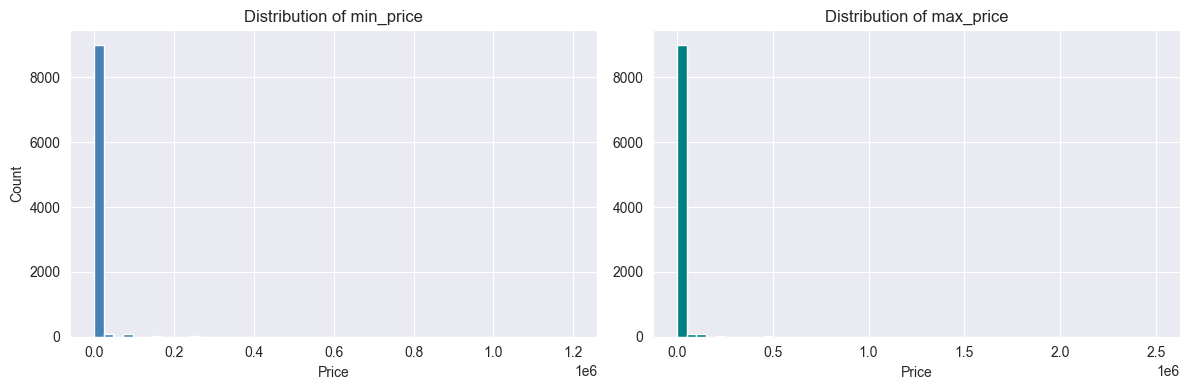

Notice: heavily right-skewed. A few very expensive projects pull the tail.
We will deal with this in Week 2.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['min_price'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of min_price')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Count')

axes[1].hist(df['max_price'], bins=50, color='teal', edgecolor='white')
axes[1].set_title('Distribution of max_price')
axes[1].set_xlabel('Price')

plt.tight_layout()
plt.show()

print('Notice: heavily right-skewed. A few very expensive projects pull the tail.')
print('We will deal with this in Week 2.')

In [10]:
df[df['client_country'].isna()].head()

,projectId,job_title,job_description,tags,client_state,client_country,client_average_rating,client_review_count,min_price,max_price,avg_price,currency,rate_type
3901,36774382,RFM kmeans,RFM kmeans Analysis to Identify Customer Segme...,"['python', 'big data sales', 'data mining', 'm...",NaN,NaN,5.0,1,750,1500,1125.0,USD,fixed


In [11]:
df.drop(['client_state','projectId'], axis=1, inplace=True)

In [12]:
df.head()

,job_title,job_description,tags,client_country,client_average_rating,client_review_count,min_price,max_price,avg_price,currency,rate_type
0,development and implementation of a federated ...,please bid only if you are ready to do the wor...,"['algorithm', 'java', 'python', 'machine learn...",Germany,5.0,17,8,30,19.0,EUR,fixed
1,Data Entry -- 2,Project Title: Data Entry - Data Analysis in E...,"['excel', 'statistical analysis', 'statistics'...",India,0.0,0,750,1250,1000.0,INR,hourly
2,Data Scrap,I am looking for a freelancer who can help me ...,"['web scraping', 'data mining', 'data entry', ...",France,5.0,1,30,250,140.0,EUR,fixed
3,Big Data Project,Store Sales Data Analysis: A Data Engineering ...,"['big data sales', 'data science', 'data minin...",India,5.0,2,5000,5500,5250.0,INR,fixed
4,Virtual Assistant / Research Assistant,Job Description: I am seeking a Virtual Assist...,"['data entry', 'virtual assistant', 'web searc...",United States,0.0,0,5,15,10.0,USD,hourly


In [13]:
df['currency'].value_counts()

currency
USD    4444
INR    2433
AUD     733
EUR     639
GBP     477
CAD     287
SGD      93
NZD      50
HKD      37
Name: count, dtype: int64

In [14]:
exchange_rates = {
    'USD': 1.0,
    'EUR': 1.10,
    'INR': 0.012,
    'SGD': 0.74,
    'GBP': 1.27,
    'AUD': 0.67,
    'HKD': 0.13,
    'CAD': 0.73,
    'NZD': 0.61
}

In [15]:
dummy = df.head(5)

In [22]:
def convert_to_usd(row, column):
    rate = exchange_rates.get(row['currency'],1)
    return row[column] * rate

In [24]:
for col in ['min_price', 'max_price', 'avg_price']:
    df[f'{col}_usd'] = df.apply(lambda row: convert_to_usd(row, col), axis=1)

df['currency'] = 'USD'

print('Prices converted to USD.')
df[['min_price', 'min_price_usd', 'max_price', 'max_price_usd']].head()

Prices converted to USD.


,min_price,min_price_usd,max_price,max_price_usd
0,8,8.8,30,33.0
1,750,9.0,1250,15.0
2,30,33.0,250,275.0
3,5000,60.0,5500,66.0
4,5,5.0,15,15.0


In [26]:
df.drop(['currency','client_average_rating','client_review_count','min_price','max_price','avg_price'],axis=1,inplace=True)

In [36]:
df.columns

Index(['job_title', 'job_description', 'tags', 'client_country', 'rate_type',
       'min_price_usd', 'max_price_usd', 'avg_price_usd'],
      dtype='object')

In [30]:

df['client_country'] = df['client_country'].replace(['',' ','NAN','nan','NA'], np.nan)
df.dropna(subset=['client_country'], inplace=True)
print('Rows after removing missing countries:', len(df))

Rows after removing missing countries: 9192


In [37]:
df= pd.get_dummies(df, columns=['rate_type'], prefix='rate')

In [38]:
# Step 2: Convert boolean to int:
df['rate_fixed'] = df['rate_fixed'].astype(int)
df['rate_hourly'] = df['rate_hourly'].astype(int)


In [39]:
print(df[['rate_fixed', 'rate_hourly']].head())





   rate_fixed  rate_hourly
0           1            0
1           0            1
2           1            0
3           1            0
4           0            1


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9192 entries, 0 to 9192
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   job_title        9192 non-null   object 
 1   job_description  9192 non-null   object 
 2   tags             9192 non-null   object 
 3   client_country   9192 non-null   object 
 4   min_price_usd    9192 non-null   float64
 5   max_price_usd    9192 non-null   float64
 6   avg_price_usd    9192 non-null   float64
 7   rate_fixed       9192 non-null   int64  
 8   rate_hourly      9192 non-null   int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 718.1+ KB


In [42]:
print('Type:', type(df['tags'].iloc[0]))
print('Value:', df['tags'].iloc[0])

Type: <class 'str'>
Value: ['algorithm', 'java', 'python', 'machine learning (ml)', 'flutter']


In [43]:
import ast

def process_tags(tag_str):
    tag_list = ast.literal_eval(tag_str)
    return ', '.join(tag_list)

df['tags_clean'] = df['tags'].apply(process_tags)

df[['tags', 'tags_clean']].head(3)

,tags,tags_clean
0,"['algorithm', 'java', 'python', 'machine learn...","algorithm, java, python, machine learning (ml)..."
1,"['excel', 'statistical analysis', 'statistics'...","excel, statistical analysis, statistics, spss ..."
2,"['web scraping', 'data mining', 'data entry', ...","web scraping, data mining, data entry, excel, ..."


In [44]:
df.drop('tags', axis=1, inplace=True)
print('Original tags column replaced by tags_clean.')

Original tags column replaced by tags_clean.


Fixed-price: 7321 rows
Hourly-rate: 1871 rows


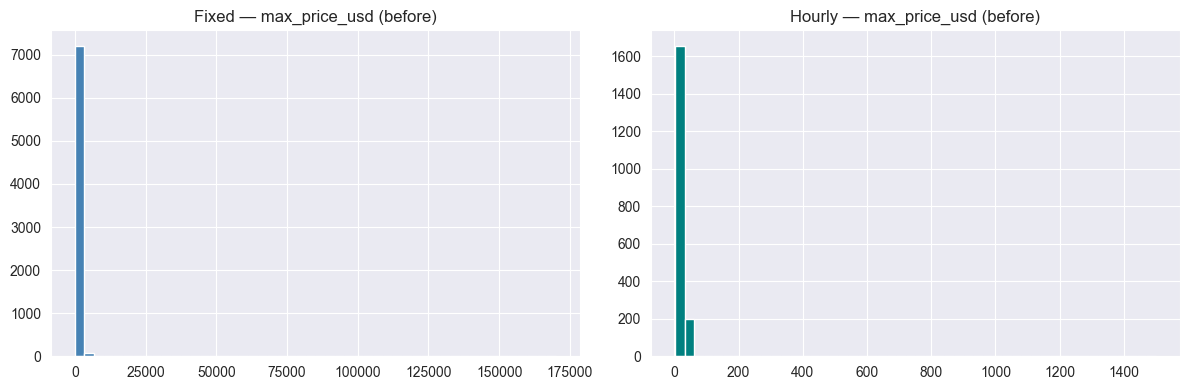

In [45]:
is_fixed = df['rate_fixed'] == 1
fixed_df = df[is_fixed].copy()
hourly_df = df[~is_fixed].copy()

print(f'Fixed-price: {len(fixed_df)} rows')
print(f'Hourly-rate: {len(hourly_df)} rows')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(fixed_df['max_price_usd'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Fixed — max_price_usd (before)')
axes[1].hist(hourly_df['max_price_usd'], bins=50, color='teal', edgecolor='white')
axes[1].set_title('Hourly — max_price_usd (before)')
plt.tight_layout()

In [46]:
def remove_outliers(df, column, name):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR

    n_before = len(df)
    df_clean = df[df[column] <= upper_bound].copy()
    n_removed = n_before - len(df_clean)

    print(f'{name}: upper bound = ${upper_bound:,.2f}')
    print(f'  Removed {n_removed} rows — {len(df_clean)} remain')
    return df_clean


fixed_df = remove_outliers(fixed_df, 'max_price_usd', 'Fixed-price')
hourly_df = remove_outliers(hourly_df, 'max_price_usd', 'Hourly-rate')

Fixed-price: upper bound = $748.75
  Removed 1322 rows — 5999 remain
Hourly-rate: upper bound = $49.00
  Removed 149 rows — 1722 remain


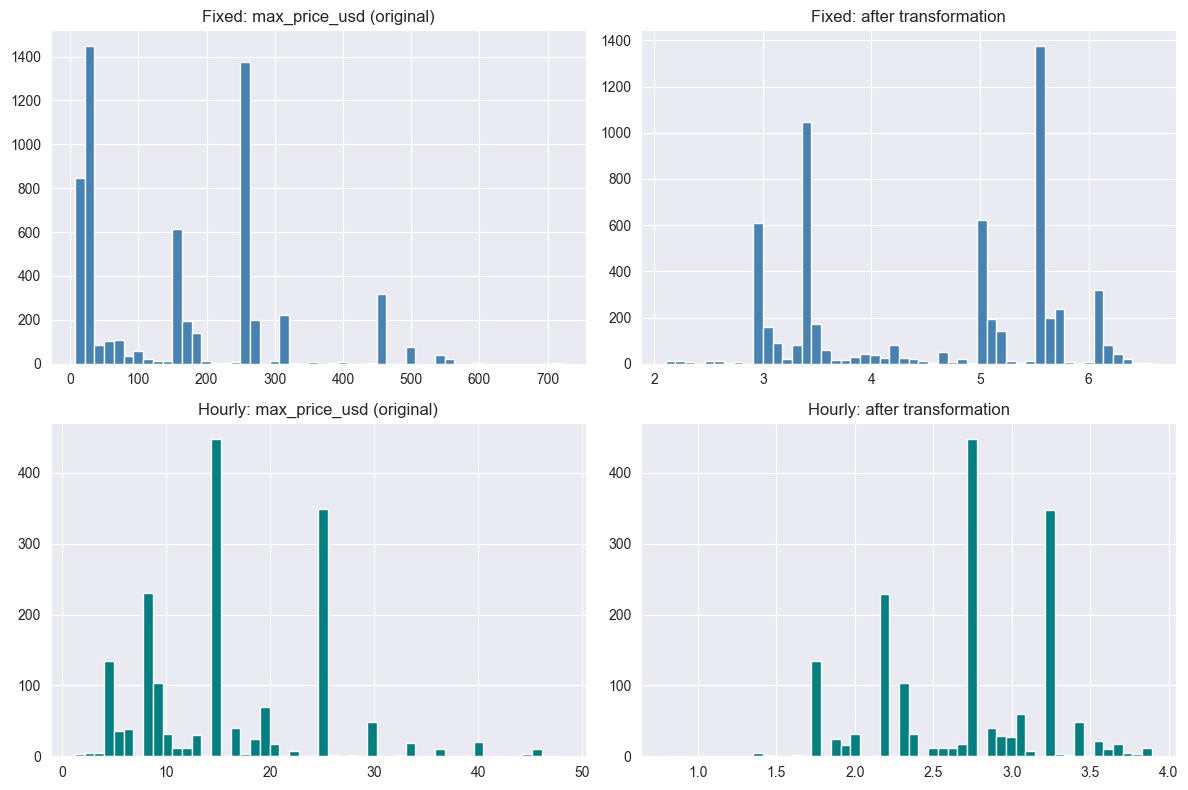

Much more balanced. This is the scale the model will train on.


In [47]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(fixed_df['max_price_usd'], bins=50, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Fixed: max_price_usd (original)')

axes[0, 1].hist(np.log1p(fixed_df['max_price_usd']), bins=50, color='steelblue', edgecolor='white')
axes[0, 1].set_title('Fixed: after transformation')

axes[1, 0].hist(hourly_df['max_price_usd'], bins=50, color='teal', edgecolor='white')
axes[1, 0].set_title('Hourly: max_price_usd (original)')

axes[1, 1].hist(np.log1p(hourly_df['max_price_usd']), bins=50, color='teal', edgecolor='white')
axes[1, 1].set_title('Hourly: after transformation')

plt.tight_layout()
plt.show()

print('Much more balanced. This is the scale the model will train on.')

In [48]:
original    = 250.0
transformed = np.log1p(original)
recovered   = np.expm1(transformed)

print(f'Original:     ${original}')
print(f'After log1p:  {transformed:.4f}')
print(f'After expm1:  ${recovered:.2f}  <-- back to original')

Original:     $250.0
After log1p:  5.5255
After expm1:  $250.00  <-- back to original


In [49]:
print('=== FIXED PRICE DATASET ===')
print(f'Rows:    {len(fixed_df)}')
print(f'Columns: {list(fixed_df.columns)}')
print()
print('=== HOURLY RATE DATASET ===')
print(f'Rows:    {len(hourly_df)}')
print(f'Columns: {list(hourly_df.columns)}')

=== FIXED PRICE DATASET ===
Rows:    5999
Columns: ['job_title', 'job_description', 'client_country', 'min_price_usd', 'max_price_usd', 'avg_price_usd', 'rate_fixed', 'rate_hourly', 'tags_clean']

=== HOURLY RATE DATASET ===
Rows:    1722
Columns: ['job_title', 'job_description', 'client_country', 'min_price_usd', 'max_price_usd', 'avg_price_usd', 'rate_fixed', 'rate_hourly', 'tags_clean']


In [56]:
df

,job_title,job_description,client_country,min_price_usd,max_price_usd,avg_price_usd,rate_fixed,rate_hourly,tags_clean
0,development and implementation of a federated ...,please bid only if you are ready to do the wor...,Germany,8.80,33.00,20.9,1,0,"algorithm, java, python, machine learning (ml)..."
1,Data Entry -- 2,Project Title: Data Entry - Data Analysis in E...,India,9.00,15.00,12.0,0,1,"excel, statistical analysis, statistics, spss ..."
2,Data Scrap,I am looking for a freelancer who can help me ...,France,33.00,275.00,154.0,1,0,"web scraping, data mining, data entry, excel, ..."
3,Big Data Project,Store Sales Data Analysis: A Data Engineering ...,India,60.00,66.00,63.0,1,0,"big data sales, data science, data mining, sta..."
4,Virtual Assistant / Research Assistant,Job Description: I am seeking a Virtual Assist...,United States,5.00,15.00,10.0,0,1,"data entry, virtual assistant, web search, exc..."
...,...,...,...,...,...,...,...,...,...
9188,Computer Vision / Feature Extraction from Aeri...,Looking for an experienced computer vision / f...,Argentina,30.00,250.00,140.0,1,0,"python, deep learning, computer vision, image ..."
9189,Database and software analysis,I need a freelancer who's proficient in micros...,United Kingdom,250.00,750.00,500.0,1,0,data processing
9190,Business Analyst (Strategic Projects) -- 2,Role Purpose The role’s purpose is to superch...,Australia,10.05,16.75,13.4,0,1,"python, business analysis, financial analysis,..."
9191,AI developer needed,We are an italian startup seeking for a machin...,Italy,3300.00,5500.00,4400.0,1,0,"data analysis, machine learning (ml), python"


In [51]:
from sentence_transformers import SentenceTransformer
print('sentence_transformers imported.')

C:\Users\shahr\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



sentence_transformers imported.


In [53]:
model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')
print('Model loaded.')

Model loaded.


In [57]:
df["text_for_embedding"] = (
     df["job_title"].astype(str) + " | " +
     df['job_description'] + " | " +
     df['tags_clean']
 )


In [58]:
embeddings = model.encode(df["text_for_embedding"].tolist(), show_progress_bar=True)

print('Shape:', embeddings.shape)
# (9192 rows, 768 numbers per row)

df["embeddings"] = embeddings.tolist()


Batches: 100%|██████████| 288/288 [46:07<00:00,  9.61s/it] 


Shape: (9192, 768)


In [60]:
df.head()

,job_title,job_description,client_country,min_price_usd,max_price_usd,avg_price_usd,rate_fixed,rate_hourly,tags_clean,text_for_embedding,embeddings
0,development and implementation of a federated ...,please bid only if you are ready to do the wor...,Germany,8.8,33.0,20.9,1,0,"algorithm, java, python, machine learning (ml)...",development and implementation of a federated ...,"[-0.0010374323464930058, 0.025920268148183823,..."
1,Data Entry -- 2,Project Title: Data Entry - Data Analysis in E...,India,9.0,15.0,12.0,0,1,"excel, statistical analysis, statistics, spss ...",Data Entry -- 2 | Project Title: Data Entry -...,"[0.013640345074236393, 0.07931940257549286, -0..."
2,Data Scrap,I am looking for a freelancer who can help me ...,France,33.0,275.0,154.0,1,0,"web scraping, data mining, data entry, excel, ...",Data Scrap | I am looking for a freelancer who...,"[0.056175991892814636, 0.0792161151766777, -0...."
3,Big Data Project,Store Sales Data Analysis: A Data Engineering ...,India,60.0,66.0,63.0,1,0,"big data sales, data science, data mining, sta...",Big Data Project | Store Sales Data Analysis: ...,"[-0.010524364188313484, 0.042077064514160156, ..."
4,Virtual Assistant / Research Assistant,Job Description: I am seeking a Virtual Assist...,United States,5.0,15.0,10.0,0,1,"data entry, virtual assistant, web search, exc...",Virtual Assistant / Research Assistant | Job ...,"[0.05351154878735542, 0.013150404207408428, -0..."


In [64]:
df.to_pickle('dataset_with_embeddings.pkl')


In [61]:
# df = pd.read_pickle("dataset_with_embeddings.pkl")

print('Rows:', len(df))
print('Columns:', list(df.columns))
print('Embedding size:', len(df["embeddings"].iloc[0]))

Rows: 9192
Columns: ['job_title', 'job_description', 'client_country', 'min_price_usd', 'max_price_usd', 'avg_price_usd', 'rate_fixed', 'rate_hourly', 'tags_clean', 'text_for_embedding', 'embeddings']
Embedding size: 768


In [62]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

idx_a, idx_b, idx_c = 0, 3, 1

e_a = np.array(df["embeddings"].iloc[idx_a]).reshape(1, -1)
e_b = np.array(df["embeddings"].iloc[idx_b]).reshape(1, -1)
e_c = np.array(df["embeddings"].iloc[idx_c]).reshape(1, -1)

print(f'Job A: {df["job_title"].iloc[idx_a][:60]}')
print(f'Job B: {df["job_title"].iloc[idx_b][:60]}')
print(f'Job C: {df["job_title"].iloc[idx_c][:60]}')
print()
print(f'Similarity A vs B: {cosine_similarity(e_a, e_b)[0][0]:.4f}')
print(f'Similarity A vs C: {cosine_similarity(e_a, e_c)[0][0]:.4f}')
print()
print('Similar jobs should score higher than unrelated ones.')

Job A: development and implementation of a federated learning syste
Job B: Big Data Project
Job C: Data Entry  -- 2

Similarity A vs B: 0.2691
Similarity A vs C: 0.2076

Similar jobs should score higher than unrelated ones.


In [65]:
import numpy as np
import joblib
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

df = pd.read_pickle('dataset_with_embeddings.pkl')
print(f'Loaded {len(df)} rows, {len(df.columns)} columns')

Loaded 9192 rows, 11 columns


In [66]:
from sklearn.preprocessing import LabelEncoder
import joblib

country_encoder = LabelEncoder()
df['country_encoded'] = country_encoder.fit_transform(df['client_country'])
num_countries = len(country_encoder.classes_)

joblib.dump(country_encoder, 'country_encoder.joblib')
print(f'Total countries: {num_countries}')
print('Sample mapping:')
for country, code in zip(df['client_country'].iloc[:3], df['country_encoded'].iloc[:3]):
    print(f'  {country} → {code}')

Total countries: 177
Sample mapping:
  Germany → 59
  India → 69
  France → 57


In [67]:
is_fixed  = df['rate_fixed'] == 1
fixed_df  = df[is_fixed].copy()
hourly_df = df[~is_fixed].copy()

def remove_outliers(df, column, name):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    n_before = len(df)
    df_clean = df[df[column] <= upper_bound].copy()
    print(f'{name}: removed {n_before - len(df_clean)} rows → {len(df_clean)} remain')
    return df_clean

fixed_df  = remove_outliers(fixed_df,  'avg_price_usd', 'Fixed-price')
hourly_df = remove_outliers(hourly_df, 'avg_price_usd', 'Hourly-rate')

Fixed-price: removed 1328 rows → 5993 remain
Hourly-rate: removed 25 rows → 1846 remain


In [68]:
embedding_dim = len(df['embeddings'].iloc[0])  # 768

def build_model(embedding_dim, num_countries):
    text_in    = layers.Input(shape=(embedding_dim,), name='text_embeddings')
    country_in = layers.Input(shape=(1,), name='country')

    country_emb = layers.Embedding(input_dim=num_countries + 1, output_dim=16)(country_in)
    country_emb = layers.Flatten()(country_emb)
#  [768 size vector]+ [16 size vector] = 784 size vector
#[1,2,3,4,,...768]=+[1,2,3,4,5...16]=[1,2,3,4.....]
    x = layers.Concatenate()([text_in, country_emb])
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu')(x)
    output = layers.Dense(1, activation='linear', name='avg_price')(x)

    return Model(inputs=[text_in, country_in], outputs=output)

In [69]:
def train_model(df, name, save_path):
    train_data, test_data = train_test_split(df, test_size=0.2, random_state=42)

    y_log_train = np.log1p(train_data['avg_price_usd'].values)
    y_log_test  = np.log1p(test_data['avg_price_usd'].values)

    X_train = {
        'text_embeddings': np.array(train_data['embeddings'].tolist()),
        'country': train_data['country_encoded'].values
    }
    X_test = {
        'text_embeddings': np.array(test_data['embeddings'].tolist()),
        'country': test_data['country_encoded'].values
    }

    model = build_model(embedding_dim, num_countries)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='huber')




    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    model.fit(X_train, y_log_train,
              validation_data=(X_test, y_log_test),
              epochs=100, batch_size=32,
              callbacks=[early_stop], verbose=1)

    log_preds = model.predict(X_test)
    preds     = np.expm1(log_preds.flatten())
    actual    = test_data['avg_price_usd'].values

    mae  = mean_absolute_error(actual, preds)
    rmse = np.sqrt(mean_squared_error(actual, preds))
    print(f'\n{name} — MAE: ${mae:,.2f}  |  RMSE: ${rmse:,.2f}')

    model.save(save_path)
    print(f'Saved: {save_path}')

In [70]:
train_model(fixed_df,  'Fixed-price', 'fixed_price_model.keras')
train_model(hourly_df, 'Hourly-rate', 'hourly_rate_model.keras')

Epoch 1/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.4957 - val_loss: 0.5071
Epoch 2/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5102 - val_loss: 0.4829
Epoch 3/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4754 - val_loss: 0.4742
Epoch 4/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4405 - val_loss: 0.4677
Epoch 5/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4271 - val_loss: 0.4623
Epoch 6/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4249 - val_loss: 0.4560
Epoch 7/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4030 - val_loss: 0.4579
Epoch 8/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4023 - val_loss: 0.4652
Epoch 9/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4014 - val_loss: 0.4504
Epoch 10/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3736 - val_loss: 0.4541
Epoch 11/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3511 - val_loss: 0.4474
Epoch 12/100
150/150 ━━━━━━━━━━━━━━━━━━━━